# Physics-Informed Neural Network Implementation on Quadrotor Data

Importing needed libraries

In [1]:
import torch
import torch.optim
import torch.nn as nn
import torch.nn.functional as F
import copy
import numpy as np
import matplotlib.pyplot as plt
import random
import pandas as pd
from torch.distributions import Normal, Independent, kl_divergence
from collections import namedtuple
from math import e, cos, sin, pi, atan2, asin, sqrt, tan

### Quadrotor Dynamical Data Generator

In [2]:
class Quadrotor_Dynamics_Generator():

  def __init__(self,
               x_size=23,
               y_size=12,
               traj_length=2,
               normalize=True,
               xy_offset=20,
               min_Z=0,
               max_Z=50,
               xydot_offset=60.0,
               min_Zdot = -30,
               max_Zdot = 30,
               min_accel_xy = -50,
               max_accel_xy = 50,
               min_accel_z = -50,
               max_accel_z = 50, 
               min_omega=-80,
               max_omega=80,
               min_omegadot=-80,
               max_omegadot=80,
               min_rp = -pi/2 + 0.1,
               max_rp = pi/2 - 0.1,
               min_rotor_rps = 0,
               max_rotor_rps = 1000,
               perturb_rps=10,
               ground_effect=False,
               Z_thresh=2,
               quad_mass=20,
               device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
              ):

    self.device = device
    self.x_size = x_size
    self.y_size = y_size
    self.traj_length = traj_length
    self.normalize = normalize
    self.xy_offset = xy_offset
    self.min_Z = min_Z
    self.max_Z = max_Z
    self.xydot_offset = xydot_offset

    self.min_rp = min_rp
    self.max_rp = max_rp
    self.min_rotor_bound = min_rotor_rps
    self.max_rotor_bound = max_rotor_rps
    self.perturb_rps = perturb_rps
    self.ground_effect = ground_effect
    self.Z_thresh = Z_thresh
    self.m = quad_mass
    self.constants = self.constants_init()

    # Initialize minmax data needed for relavent simulation parameters
    self.minmax_data = torch.tensor([[-self.xydot_offset, self.xydot_offset],
                                    [-self.xydot_offset, self.xydot_offset],
                                    [min_Zdot, max_Zdot],
                                    [min_accel_xy, max_accel_xy],
                                    [min_accel_xy, max_accel_xy],
                                    [min_accel_z, max_accel_z],
                                    [min_omega, max_omega],
                                    [min_omega, max_omega],
                                    [min_omega, max_omega],
                                    [min_omegadot, max_omegadot],
                                    [min_omegadot, max_omegadot],
                                    [min_omegadot, max_omegadot],
                                    [0, 0], #dt
                                    [min_rotor_rps, max_rotor_rps],
                                    [min_rotor_rps, max_rotor_rps],
                                    [min_rotor_rps, max_rotor_rps],
                                    [min_rotor_rps, max_rotor_rps],
                                    [0, 0],
                                    [0, 0],
                                    [0, 0],
                                    [0, 0],
                                    [0, 0],
                                    [0, 0],
                                    [-self.xydot_offset, self.xydot_offset],
                                    [-self.xydot_offset, self.xydot_offset],
                                    [min_Zdot, max_Zdot],
                                    [min_accel_xy, max_accel_xy],
                                    [min_accel_xy, max_accel_xy],
                                    [min_accel_z, max_accel_z],
                                    [min_omega, max_omega],
                                    [min_omega, max_omega],
                                    [min_omega, max_omega],
                                    [min_omegadot, max_omegadot],
                                    [min_omegadot, max_omegadot],
                                    [min_omegadot, max_omegadot]])
    

  # Evolves the dynamics of quadrotor
  def eqn_mtn(self, state_vec, uu, dt, V_w, rotor_disturbances=False, rotor_spike_bound=200, linvel_offset=torch.zeros([3,]), angvel_offset=torch.zeros([3,])):

    ########     NESTED FUNCTION     ########

    # Verify boundness of Euler angles
    def theta_check(theta):
      # Parsing euler angles
      roll = theta[0]
      pitch = theta[1]
      yaw = theta[2]

      # Ensuring euler angles remain within [-pi, pi]
      roll_offset = torch.abs(torch.floor(roll / (2*pi)))
      pitch_offset = torch.abs(torch.floor(pitch / (2*pi)))
      yaw_offset = torch.abs(torch.floor(yaw / (2*pi)))

      if roll > pi:
        roll -= roll_offset * (2*pi)
      elif roll < -pi:
        roll += roll_offset * (2*pi)

      if pitch > pi:
        pitch -= pitch_offset * (2*pi)
      elif pitch < -pi:
        pitch += pitch_offset * (2*pi)

      if yaw > pi:
        yaw -= yaw_offset * (2*pi)
      elif yaw < -pi:
        yaw += yaw_offset * (2*pi)

      theta_transformed = torch.tensor([roll, pitch, yaw])
      return theta_transformed
    
    ###########   END OF NESTED FUNCTION   ###########
    
    # Parsing positional and velocity states
    x = state_vec[:3]
    theta = state_vec[3:6]
    xdot = state_vec[6:9]
    thetadot = state_vec[9:12]
    omega = state_vec[12:15]
    omegadot = state_vec[15:18]
    a = state_vec[18:]
    
    # Checking if current altitude is at ground effect threshold  
    if x[2] <= 2 and x[2] > 0:
      self.ground_effect = True
    else:
      self.ground_effect = False  
      
   # print(f'EQN_MTN BEFORE: xdot_prev: {xdot}, a: {a}, omega_prev: {omega}, omegadot: {omegadot}')


    # Initializing needed constants
    I = self.constants['I']
    I_r = self.constants['I_r']
    g = self.constants['g']
    m = self.constants['m']
    L = self.constants['L']
    b = self.constants['b']
    kf = self.constants['kf']
    km = self.constants['km']
    kd = self.constants['kd']
    d_array = self.constants['d_array']


    # Incorporating rotor spiking (if applicable)
    if rotor_disturbances == True:
      uu_observed = uu.clone()
      uu = self.perturb_rv(uu_observed, rotor_spike_bound=rotor_spike_bound)

    # Integrating body rates
    omega = omega + dt * omegadot

    # Ensuring commanded velocities keep quadrotor within defined state space
    if linvel_offset.any():
      xdot = linvel_offset
    else:
      xdot = xdot + dt * a
      
    if angvel_offset.any():
      thetadot = angvel_offset
    else: 
      thetadot = self.omega2thetadot(omega, theta)

    # Integrating positional states
    theta = theta + dt * thetadot
    x = x + dt * xdot

    # Ensuring euler angles lie within appropriate bounds
    theta = theta_check(theta)
    
    # Transforming inputs into $\omega_{i}^2$
    uu = torch.pow(uu, 2)

    # Computing quadrotor body rates from updated euler data
    omega = self.thetadot2omega(thetadot, theta)
    
    # Computing forces and moments from external perturbations
    V_w, F_w = self.inject_wind_peturb(V_w, dt)
    Vr_array = self.compute_rotor_linvels(xdot, theta, omega, d_array, V_w)
    F_bf, F_bf_array = self.inject_blade_flapping_force(theta, uu, Vr_array)
    F_id, F_id_array = self.inject_induced_drag_force(theta, uu, Vr_array)
    
    if self.ground_effect: 
      Fg = self.inject_ground_effect(z=x[2],z_thresh=2)
    else:
      Fg = torch.zeros_like(F_bf)

    # Computing exogenous disturbances
    F_aero = F_bf + F_id + Fg + F_w
    tau_aero = self.inject_torque_perturb(F_bf_array, F_id_array, d_array)
    
    # Compute linear and angular accelerations.
    a = self.acceleration(uu, theta, xdot, m, g, kf, kd, F_aero, prev_a=a)
    omegadot = self.angular_acceleration(uu, omega, I, I_r, L, b, km, tau_aero, prev_ωdot=omegadot)

    # Updating state vector
    state_vec = torch.concat([x, theta, xdot, thetadot, omega, omegadot, a], dim=0)
    #print(f'EQN_MTN AFTER: xdot_prev: {xdot}, a: {a}, omega_prev: {omega}, omegadot: {omegadot}, V_w: {V_w}')
    
    return state_vec, V_w, F_aero, tau_aero
  
  ####   QUADROTOR PHYSICS FUNCTIONS   ####
  
  # Compute translational accelerations
  def acceleration(self, inputs, angles, xdot, m, g, kf, kd, F_aero, prev_a=torch.zeros([3,])):
    gravity = torch.tensor([0,0,-g])
    R = self.rotation(angles)
    T = R @ self.thrust(inputs, kf)
    Fd = -kd * xdot
    a = gravity + (1/m) * (T + Fd + F_aero) - kd * prev_a
    return a

  # Compute angular accelerations
  def angular_acceleration(self, inputs, omega, I, I_r, L, b, km, tau_aero, prev_ωdot=torch.zeros([3,])):
    tau_m = self.motor_torques(inputs, L, b, km)
    tau_g = self.gyroscopic_torques(inputs, omega, I_r)
    
    #print(f'tau_m: {tau_m}, tau_aero: {tau_aero}, tau_g: {tau_g}\n')
    tau = (tau_m + tau_aero - tau_g)
    omegadot = torch.inverse(I) @ (tau - torch.linalg.cross(omega, I @ omega)) - km * prev_ωdot
    return omegadot
  
  # Compute torques, given current inputs, length of arm, drag coefficient, and moment coefficient.
  def motor_torques(self, inputs, L, b, km):
    # Inputs are values for ${\omega_i}^2$
    tau = torch.tensor([
        L * km * (inputs[0] - inputs[2]),
        L * km * (inputs[1] - inputs[3]),
        b * (inputs[0] - inputs[1] + inputs[2] - inputs[3])
    ])
    return tau
  
  # Compute thrust given current inputs and thrust coefficient.
  def thrust(self, inputs, kf):
    # Inputs are values for ${\omega_i}^2$
    T = torch.tensor([0, 0, kf * torch.sum(inputs)])
    return T

  # Compute gyroscopic torques on quadrotor
  def gyroscopic_torques(self, inputs, omega, I_r):
    # Parsing body rates
    pp = omega[0]
    qq = omega[1]
    
    # Untransforming squared inputs
    inputs = torch.sqrt(inputs)
    
    # Computing gyroscopic torques
    tau_g = torch.zeros([3,])
    tau_g[0] = I_r*qq*(inputs[0] - inputs[1] + inputs[2] - inputs[3])
    tau_g[1] = -I_r*pp*(inputs[0] - inputs[1] + inputs[2] - inputs[3])
    
    return tau_g

  ####    END OF PHYSICS FUNCTIONS     ####


  ####  PERTURBATION/NOISE FUNCTIONS   ####

  def perturb_rv(self, uu, rotor_spike_bound=200):

    # High: perturb_rps minmax = -100, 100
    # Medium: perturb_rps_minmax = -50, 50

    max_rotor_perturb_rps = rotor_spike_bound
    min_rotor_perturb_rps = -rotor_spike_bound
    
    # Sampling rotor spiking values
    dω1 = random.random() * (max_rotor_perturb_rps - min_rotor_perturb_rps) + min_rotor_perturb_rps
    dω2 = random.random() * (max_rotor_perturb_rps - min_rotor_perturb_rps) + min_rotor_perturb_rps
    dω3 = random.random() * (max_rotor_perturb_rps - min_rotor_perturb_rps) + min_rotor_perturb_rps
    dω4 = random.random() * (max_rotor_perturb_rps - min_rotor_perturb_rps) + min_rotor_perturb_rps
    
    # Applying spiking values to rotor velocities
    uu[0] += dω1
    uu[1] += dω2
    uu[2] += dω3
    uu[3] += dω4

     # Applying saturation limits
    for rotor in range(uu.shape[0]):
      if uu[rotor] > self.max_rotor_bound:
        uu[rotor] = self.max_rotor_bound - 20
      elif uu[rotor] < self.min_rotor_bound:
        uu[rotor] = self.min_rotor_bound + 20
    
    return uu
  
  def model_rotor_vels(self, uu, noise_bias=10, noise_std=15):
    
    # Sampling noise vector to perturb rotor velocities in realistic manner
    noise_uu = torch.normal(mean=torch.tensor(noise_bias), std=torch.tensor(noise_std), size=[4,])
    
    # Applying noise to rotor velocities
    uu += noise_uu
    
    # Applying saturation limits
    for rotor in range(uu.shape[0]):
      if uu[rotor] > self.max_rotor_bound:
        uu[rotor] = self.max_rotor_bound - 20
      elif uu[rotor] < self.min_rotor_bound:
        uu[rotor] = self.min_rotor_bound + 20
    
    # Applying quantization step
    uu = torch.round(uu)
    
    return uu


  def compute_rotor_linvels(self, xdot, theta, omega, d_array, V_w):
    # VECTORIZE
    
    # Computing rotation matrix for  (Body -> Inertial)
    R = self.rotation(theta)

    # Computing rotor linear velocities for each rotor
    Vr_array = torch.zeros([4,3])
    for rotor in range(4):
      Vr_array[rotor,:] = R.T @ (xdot - V_w) + torch.linalg.cross(omega, d_array[rotor,:])
    
    return Vr_array
    

  def inject_blade_flapping_force(self, theta, uu, Vr_array):
    # VECTORIZE
    
    # Defining needed aerodynamic coefficients
    Ct = 2e-3
    Ca = 5e-4
    Cb = 5e-4

    # Computing rotation matrix  (Body -> Inertial)
    R = self.rotation(theta)

    # Computing sum of blade flapping forces coming from all rotors
    F_bf = torch.zeros([3,])
    F_bf_array = torch.zeros([4,3])
    mat = torch.tensor([[Ca,-Cb,0],
                        [Cb,Ca,0],
                        [0,0,0]])
    
    for rotor in range(uu.shape[0]):
      rotor_F_bf = -Ct * uu[rotor] * R @ mat @ Vr_array[rotor,:]
      F_bf += rotor_F_bf
      F_bf_array[rotor,:] = rotor_F_bf

    return F_bf, F_bf_array

  def inject_induced_drag_force(self, theta, uu, Vr_array):
    # VECTORIZE
    # Defining needed aerodynamic coefficients
    Ct = 2e-3
    Cdx = 5e-4
    Cdy = 5e-4

    # Computing rotation matrix  (Body -> Inertial)
    R = self.rotation(theta)

    # Computing sum of induced drag forces from all rotors
    F_id = torch.zeros(3,)
    F_id_array = torch.zeros([4,3]) 
    mat = torch.tensor([[Cdx,0,0],
                        [0,Cdy,0],
                        [0,0,0]])
    
    for rotor in range(uu.shape[0]):
      rotor_F_id = -Ct * uu[rotor] * R @ mat @ Vr_array[rotor,:]
      F_id += rotor_F_id
      F_id_array[rotor,:] = rotor_F_id

    return F_id, F_id_array
  
  def inject_ground_effect(self, z, z_thresh):
  
    # Defining needed aerodynamic coefficient
    Cg = 1e-3

    # Computing ground effect force
    Fg_coeff = Cg / (4*z**2) - Cg / (z_thresh - z) ** 2
    Fg = Fg_coeff * torch.tensor([0,0,1])
    
    # Computing maximum allowed ground effect force based on quadrotor weight
    Fg_max = 0.4 * (self.m * 9.8)
    
    # Constraining ground effect force to be within realistic bounds
    if Fg[2] > Fg_max:
      Fg[2] = Fg_max
    elif Fg[2] < -Fg_max:
      Fg[2] = -Fg_max

    return Fg


  def inject_torque_perturb(self, F_bf_array, F_id_array, d_array):
    # VECTORIZE
    def skew_symmetric(d):
      Sd = torch.tensor([[0,-d[2],d[1]],
                        [d[2],0,-d[0]],
                        [-d[1],d[0],0]])
      return Sd

    tau_perturb = torch.zeros([3,])
    for rotor in range(4):
      d = d_array[rotor,:]
      F_bf = F_bf_array[rotor,:]
      F_id = F_id_array[rotor,:] 

      Sd = skew_symmetric(d)

      tau_perturb += Sd @ (F_bf + F_id)
    
    return tau_perturb
  
  def inject_wind_peturb(self, V_w, dt):
  
    # Computing matrices needed for wind update
    w_array1 = torch.tensor([80,75,24], dtype=torch.float32)
    w_array1 = torch.diag(w_array1)

    w_array2 = torch.tensor([1.65,1.5,1.9])
    w_array2 = torch.inverse(torch.diag(w_array2))

    # Computing updated wind force
    F_w = torch.tensor([
                    0.05 * V_w[0]**2 * torch.sign(V_w[0]), 
                    0.05 * V_w[1]**2 * torch.sign(V_w[1]),
                    0.1 * V_w[2]**2 * torch.sign(V_w[2])
                  ])

    # Computing updated wind velocity
    w_d = torch.normal(mean=0, std=0.2, size=[3,])
    V_wdot = w_array2 @ (-V_w + w_array1 @ w_d)

    V_w += V_wdot * dt
    
    return V_w, F_w
  

  def apply_mm_gaussian_noise(self, xdot, a, ω, ωdot, max_num_peaks=5, num_points=500, gps_err_bias1=5e-2, gps_err_std1=1e-2, gyro_err_bias1=1e-2, gyro_err_std1=5e-2, 
                              gps_err_bias2=5e-1, gps_err_std2=6e-1, gyro_err_bias2=5e-1, gyro_err_std2=1.0, max_motion_scale=6e-3, min_motion_scale=5e-4):

    # Large Noise: gps_err_bias=0.2, gps_err_std=0.6, gyro_err_bias=5e-1, gyro_err_std=1e-3
    # Medium Noise: gps_err_bias=5e-2, gps_err_std=6e-3, gyro_err_bias=1e-2, gyro_err_std=1e-3

    # Preventing in-place computations
    xdot = xdot.clone()
    a = a.clone()
    ω = ω.clone()
    ωdot = ωdot.clone()
  
    num_peaks = random.randint(2,max_num_peaks)
    peak_weights = torch.rand([num_peaks,])
    peak_weights /= torch.sum(peak_weights)

    for i in range(num_peaks):
      
      # Computing sample size for noise peak
      N = int(torch.ceil(num_points * peak_weights[i])) if int(torch.ceil(num_points * peak_weights[i])) > 3 else 3

      # Sampling sensor noise characteristics
      gps_err_bias = random.random() * (gps_err_bias2 - gps_err_bias1) + gps_err_bias1
      gps_err_std = random.random() * (gps_err_std2 - gps_err_std1) + gps_err_std1
      gyro_err_bias = random.random() * (gyro_err_bias2 - gyro_err_bias1) + gyro_err_bias1
      gyro_err_std = random.random() * (gyro_err_std2 - gyro_err_std1) + gyro_err_std1

      # Instantiating zero-mean gaussian noise for translational and angular data
      noise_xdot = torch.normal(mean=torch.tensor(gps_err_bias), std=torch.tensor(gps_err_std), size=[N,])
      noise_a = torch.normal(mean=torch.tensor(gps_err_bias*1.5), std=torch.tensor(gps_err_std*1.5), size=[N,])
      noise_ω = torch.normal(mean=torch.tensor(gyro_err_bias), std=torch.tensor(gyro_err_std), size=[N,])
      noise_ωdot = torch.normal(mean=torch.tensor(gyro_err_bias*1.5), std=torch.tensor(gyro_err_std*1.5), size=[N,])

      # Shuffle the elements of the multimodal distribution
      shuffled_dist_xdot = noise_xdot[torch.randperm(len(noise_xdot))]
      shuffled_dist_a = noise_a[torch.randperm(len(noise_a))]
      shuffled_dist_ω = noise_ω[torch.randperm(len(noise_ω))]
      shuffled_dist_ωdot = noise_ωdot[torch.randperm(len(noise_ωdot))]

      # Parsing multimodal gaussian noise to disrupt sensor data
      noise_xdot = shuffled_dist_xdot[torch.randperm(3)]
      noise_a = shuffled_dist_a[torch.randperm(3)]
      noise_ω = shuffled_dist_ω[torch.randperm(3)]
      noise_ωdot = shuffled_dist_ωdot[torch.randperm(3)]


    # Applying additive/multiplicative noise to dynamic signals
    motion_scale = random.random() * (max_motion_scale - min_motion_scale) + min_motion_scale
    xdot += noise_xdot
    a += noise_a
    ω += noise_ω
    ωdot += noise_ωdot
    
    xdot *= (1 + motion_scale * xdot)
    a *= (1 + motion_scale * a)
    ω *= (1 + motion_scale * ω)
    ωdot *= (1 + motion_scale * ωdot)

    return xdot, a, ω, ωdot
  
  ####   END OF PERTURBATION/NOISE FUNCTIONS    ####
  
  # Initializing needed constants for simulation
  def constants_init(self):
      # Move constants to the specified device (GPU or CPU)
      m = torch.tensor([self.m], device=self.device)                            # Mass of quadrotor (kg)
      g = torch.tensor(9.806, device=self.device)                               # Gravitational force (m/s^2)
      L = torch.pow((m / 2.5), 1/3)                                        # Length of quadrotor arm (rotor-to-center) (m)
      r_prop = L / 4                                                      # Radius of quadrotor propellor
      A = torch.pi * r_prop**2                                             # Cross-sectional area of propellor

      # Defining inertia tensor of quadrotor (kg*m^2)
      I = torch.zeros([3, 3], device=self.device)
      I[0, 0] = 0.35 * m
      I[1, 1] = 0.35 * m
      I[2, 2] = 0.40 * m

      # Defining rotor inertia (kg*m^2)
      I_r = 4e-5 * self.m * L**2

      # Defining quadrotor aerodynamic properties
      force_reg = torch.tensor(1e-3, device=self.device)
      torque_reg = torch.tensor(5e-4, device=self.device)
      rho = torch.tensor(1.225, device=self.device)                             # Air density (kg/m^3)
      ω_hover = torch.sqrt((m * g) / (4 * 1e-3))                           # Angular velocity of rotors needed to hover (rad/s)
      km = (2.5 * m * g) / (4 * ω_hover**2) * torque_reg                  # Aerodynamic moment coefficient (N*s^2)
      kf = 5e-3 * force_reg * m                                            # Aerodynamic force coefficient (N*s^2)
      C_d = torch.tensor(1.5, device=self.device)                               # Aerodynamic drag coefficient

      # Translational and moment drag coefficient
      kd = 0.5 * rho * C_d * A
      b = 0.5 * r_prop**3 * rho * C_d * A * torque_reg

      # Defining individual rotor distances to quadrotor center of mass
      d_array = torch.zeros([4, 3], device=self.device)
      rotor_angle = torch.tensor([torch.pi/4, 3*torch.pi/4, 5*torch.pi/4, 7*torch.pi/4], device=self.device)
      for rotor in range(d_array.shape[0]):
          d_array[rotor, 0] = L * torch.sin(rotor_angle[rotor])
          d_array[rotor, 1] = L * torch.cos(rotor_angle[rotor])
          d_array[rotor, 2] = 0.2 * L

      # Updating internal quadrotor inertial properties
      constants = {'I': I, 'I_r': I_r, 'g': g, 'm': m, 'L': L, 'b': b, 'kf': kf, 'km': km, 'kd': kd, 'd_array': d_array}
      return constants



  # Computing ZYZ rotation matrix (Body -> Inertial)
  def rotation(self, theta):
    # Parsing euler angles
    roll = theta[0]
    pitch = theta[1]
    yaw = theta[2]

    # Computing rotation matrix
    R = torch.tensor([[cos(roll)*cos(yaw) - cos(pitch)*sin(roll)*sin(yaw), -cos(yaw)*sin(roll) - cos(roll)*cos(pitch)*sin(yaw), sin(pitch)*sin(yaw)],
                      [cos(pitch)*cos(yaw)*sin(roll) + cos(roll)*sin(yaw), cos(roll)*cos(pitch)*cos(yaw) - sin(roll)*sin(yaw), -cos(yaw)*sin(pitch)],
                      [sin(roll)*sin(pitch), cos(roll)*sin(pitch), cos(pitch)]])

    return R

  def linvel_control(self, Z):
    # Applying appropriate translational velocity offsets based on
    # quadrotor's current pose outside of defined regions (in m/s)
    linvel_offset = torch.zeros([3,])
  
    # Altitude control.
    if Z > self.max_Z:
      linvel_offset[2] = -10
    elif Z < self.min_Z:
      linvel_offset[2] = 10

    return linvel_offset


  def roll_pitch_control(self, ROLL, PITCH):
    # Applying appropriate roll/pitch velocity offset based on
    # quadrotor's current attitude (in rad/s)
    euler_offset = torch.zeros([3,])

    if ROLL < self.min_rp:
      euler_offset[0] = pi/2
    elif ROLL > self.max_rp:
      euler_offset[0] = -(pi/2)

    if PITCH < self.min_rp:
      euler_offset[1] = pi/2
    elif PITCH > self.max_rp:
      euler_offset[1] = -(pi/2)

    return euler_offset
  

  def sample_quad_states(self, uu, rollpitch_bounds=pi/2,yaw_bounds=pi,linvel_bounds=5,angvel_bounds=2*pi,windvel_bounds=50):
    # Sample random initial simulation states
    X = random.random() * (self.xy_offset + self.xy_offset) - self.xy_offset
    Y = random.random() * (self.xy_offset + self.xy_offset) - self.xy_offset
    Z = random.random() * (self.max_Z - self.min_Z) + self.min_Z
    x = torch.tensor([X, Y, Z])
    
    # Ground effect check
    if Z <= self.Z_thresh:
      self.ground_effect=True
    else:
      self.ground_effect=False

    ROLL = random.random() * (rollpitch_bounds + rollpitch_bounds) - rollpitch_bounds
    PITCH = random.random() * (rollpitch_bounds + rollpitch_bounds) - rollpitch_bounds
    YAW = random.random() * (yaw_bounds + yaw_bounds) - yaw_bounds
    theta = torch.tensor([ROLL, PITCH, YAW])

    X_dot = random.random() * (linvel_bounds + linvel_bounds) - linvel_bounds
    Y_dot = random.random() * (linvel_bounds + linvel_bounds) - linvel_bounds
    Z_dot = random.random() * (linvel_bounds + linvel_bounds) - linvel_bounds
    xdot = torch.tensor([X_dot, Y_dot, Z_dot])

    ROLL_dot = random.random() * (angvel_bounds + angvel_bounds) - angvel_bounds
    PITCH_dot = random.random() * (angvel_bounds + angvel_bounds) - angvel_bounds
    YAW_dot = random.random() * (angvel_bounds + angvel_bounds) - angvel_bounds
    thetadot = torch.tensor([ROLL_dot, PITCH_dot, YAW_dot])

    # Initializing needed constants
    I = self.constants['I']
    I_r = self.constants['I_r']
    g = self.constants['g']
    m = self.constants['m']
    L = self.constants['L']
    b = self.constants['b']
    kf = self.constants['kf']
    km = self.constants['km']
    kd = self.constants['kd']
    d_array = self.constants['d_array']

    # Transforming inputs into $\omega_{i}^2$
    uu = torch.pow(uu, 2)

    # Computing quadrotor body rates
    omega = self.thetadot2omega(thetadot, theta)

    # Computing forces and moments from external perturbations
    V_w = torch.zeros([3,])
    V_w[0] = random.random() * (windvel_bounds + windvel_bounds) - windvel_bounds
    V_w[1] = random.random() * (windvel_bounds + windvel_bounds) - windvel_bounds
    V_w[2] = random.random() * (windvel_bounds + windvel_bounds) - windvel_bounds

    F_w = torch.tensor([
                    0.05 * V_w[0]**2 * torch.sign(V_w[0]), 
                    0.05 * V_w[1]**2 * torch.sign(V_w[1]),
                    0.1 * V_w[2]**2 * torch.sign(V_w[2])
    ])
    
    Vr_array = self.compute_rotor_linvels(xdot, theta, omega, d_array, V_w)
    F_bf, F_bf_array = self.inject_blade_flapping_force(theta, uu, Vr_array)
    F_id, F_id_array = self.inject_induced_drag_force(theta, uu, Vr_array)
    
    if self.ground_effect: 
      Fg = self.inject_ground_effect(Z,self.Z_thresh)
    else:
      Fg = torch.zeros_like(F_bf)

    F_aero = F_bf + F_id + Fg + F_w
    tau_aero = self.inject_torque_perturb(F_bf_array, F_id_array, d_array)
    
    # Computing translational+rotational accelerations from sampled states
    a = self.acceleration(uu, theta, xdot, m, g, kf, kd, F_aero)
    omegadot = self.angular_acceleration(uu, omega, I, I_r, L, b, km, tau_aero)
   # print(f'(sampled accel): {a}, omegadot: {omegadot}\n')

    # Saving randomized states into state vector
    state_vec = torch.concat([x, theta, xdot, thetadot, omega, omegadot, a], dim=0)

    return state_vec, V_w


  def state_space_verify(self, Z, ROLL, PITCH):
    # Boolean that checks if quadrotor's states are within defined state space
    state_verified = False

    if Z > self.min_Z and abs(ROLL) < self.max_rp and abs(PITCH) < self.max_rp:

      state_verified = True

    return state_verified
  
  def quad_vel_verify(self, prev_state_vec, next_state_vec, linvel_offset, pitch_offset):
    vel_verified = True
    xdot_prev = prev_state_vec[6:9]
    thetadot_prev = prev_state_vec[9:12]

    xdot_next = next_state_vec[6:9]
    thetadot_next = next_state_vec[9:12]
    
    # Check to prevent offset velocities being included in 'quadout'
    if (xdot_next == linvel_offset).any() or (xdot_prev == linvel_offset).any() or \
      (thetadot_next == pitch_offset).any() or (thetadot_prev == pitch_offset).any():
        vel_verified = False

    return vel_verified

  def thetadot2omega(self, thetadot, theta):
    # Parsing euler angles
    roll = theta[0]
    pitch = theta[1]

    # Computing rotation matrix (Inertial -> Body)
    R = torch.tensor([[1, 0, -sin(pitch)],
                      [0, cos(roll), cos(pitch)*sin(roll)],
                      [0, -sin(roll), cos(pitch)*cos(roll)]])

    # Computing angular body rates
    omega = R @ thetadot

    return omega


  def omega2thetadot(self, omega, theta):
    # Parsing euler angles
    roll = theta[0]
    pitch = theta[1]

    # Computing rotation matrix (Body -> Inertial)
    R_inv = torch.tensor([[1, sin(roll)*tan(pitch), cos(roll)*tan(pitch)],
                      [0, cos(roll), -sin(roll)],
                      [0, sin(roll)/cos(pitch), cos(roll)/cos(pitch)]])

    # Computing angular body rates
    thetadot = R_inv @ omega

    return thetadot

  
  def update_controls(self, uu, rotor_rps_bound=20):

    # Computing randomly-selected change in each rotor velocity of quadrotor
    dw1 = random.random() * (rotor_rps_bound + rotor_rps_bound) - rotor_rps_bound
    dw2 = random.random() * (rotor_rps_bound + rotor_rps_bound) - rotor_rps_bound
    dw3 = random.random() * (rotor_rps_bound + rotor_rps_bound) - rotor_rps_bound
    dw4 = random.random() * (rotor_rps_bound + rotor_rps_bound) - rotor_rps_bound

    # Updating rotor velocities
    uu[0] += dw1
    uu[1] += dw2
    uu[2] += dw3
    uu[3] += dw4

    # Applying saturation limits
    for rotor in range(uu.shape[0]):
      if uu[rotor] > self.max_rotor_bound:
        uu[rotor] = self.max_rotor_bound - 20
      elif uu[rotor] < self.min_rotor_bound:
        uu[rotor] = self.min_rotor_bound + 20

    return uu

  
  def index_data_stacker(self, dataset):
    # Parsing relevant data shapes
    num_targets = dataset.shape[0]
    stack_iters = dataset.shape[1]

    # Initializing index data objects needed for computation
    idx = torch.randperm(num_targets)
    idx = torch.unsqueeze(idx, dim=-1)
    idx_tnsr = torch.zeros([num_targets, stack_iters])

    # Updating each dimension of idx_tnsr with idx_array
    for stack in range(stack_iters):
      idx_tnsr[:,stack:stack+1] = idx

    return idx_tnsr.to(dtype=torch.int64) # ensure all entries are integers
  


  # Minmax normalization function  
  def minmax_norm(self, dataset):
    # Parsing relevant data shapes
    batch_size = dataset.shape[0]
    dynamical_data_dim = dataset.shape[1]

    dim_skips = [12] + list(range(17,23))

    for batch in range(batch_size):
      for dim in range(dynamical_data_dim):
        # Skipping sampling rate dimension to avoid normalization
        if dim in dim_skips:
          continue

        curr_sequence = dataset[batch,dim:dim+1]
        curr_min = self.minmax_data[dim,0]
        curr_max = self.minmax_data[dim,1]

        dataset[batch,dim:dim+1] = (curr_sequence - curr_min) / (curr_max - curr_min)

    return dataset

  
  # Minmax unnormalization function
  def minmax_unnorm(self, x, var=torch.tensor([])):

    state_dim = x.shape[1]

    # Unnormalizing input array trajectory-by-trajectory
    for dim in range(state_dim):

      min_value = self.minmax_data[dim, 0]
      max_value = self.minmax_data[dim, 1]

      x[:,dim] = x[:,dim] * (max_value - min_value) + min_value
      if var.any(): var[:,dim] = var[:,dim] * (max_value - min_value) + min_value

    if var.any():
      return x, var
      
    return x
  
  
  # Converting pytorch tensor into seqential (N x data dim) tensor
  def sequential_split(self, dataset):
    
    combined_quad_array = torch.empty([dataset.shape[0]*2, self.x_size+self.y_size])
    for iter,i in enumerate(range(0, 2*dataset.shape[0], 2)):

        added_inputs1 = dataset[iter:iter+1,0,12:23]
        added_inputs2 = dataset[iter:iter+1,1,12:23]

        traj1 = dataset[iter:iter+1,0,:12]
        traj2 = dataset[iter:iter+1,1,:12]
        traj3 = dataset[iter:iter+1,1,23:]

        array1 = torch.concat([traj1,added_inputs1,traj2], dim=-1)
        array2 = torch.concat([traj2,added_inputs2,traj3], dim=-1)

        traj_array = torch.concat([array1, array2], dim=0)
        combined_quad_array[i:i+2,:] = traj_array

    return combined_quad_array


  def generate_random_signs(self, size):
    # Generate random integers (0 or 1)
    random_ints = torch.randint(0, 2, (size,))
    
    # Map 0 to -1 and 1 to 1
    signs = 2 * random_ints - 1
    
    return signs
  
  def generate_test_traj(self, seq_length, perturb_params, gaussian_noise=True):
    
    # Initializing quadrotor output array
    quadout = torch.zeros([seq_length, self.traj_length, self.x_size+self.y_size])
    
    # Parsing sensor perturb parameters
    rotor_spike_bound = perturb_params[0]
    wind_profile = perturb_params[1]
    V_w = wind_profile * self.generate_random_signs(size=3)
  
    disturb_quad_at = 1
    disturbance_iter = 0
    

    # Initializing input trajectory from our controller.
    w1 = random.random() * (self.max_rotor_bound - self.min_rotor_bound) + self.min_rotor_bound
    w2 = random.random() * (self.max_rotor_bound - self.min_rotor_bound) + self.min_rotor_bound
    w3 = random.random() * (self.max_rotor_bound - self.min_rotor_bound) + self.min_rotor_bound
    w4 = random.random() * (self.max_rotor_bound - self.min_rotor_bound) + self.min_rotor_bound
    uu = torch.tensor([w1, w2, w3, w4])
      
    # Sampling initial quadrotor states
    state_vec, V_w = self.sample_quad_states(uu)
    
    # Sampling initial sampling rate
    dt = random.random() * (0.2 - 0.0001) + 0.0001

    # Saving current state as previous one
    prev_state_vec = state_vec
    
    for i in range(seq_length):

      while True:
        
        transition_complete = False
        for j in range(self.traj_length):
          
          # Integrating dynamical states
          if disturbance_iter % disturb_quad_at == 0:
            next_state_vec, _, _, _  = self.eqn_mtn(prev_state_vec, uu, dt, V_w, rotor_disturbances=True, rotor_spike_bound=rotor_spike_bound)

            # Resetting irregular disturbance count
            disturb_quad_at = np.ceil(random.random() * 10)
            disturbance_iter = 0
          else:
            next_state_vec, _, _, _ = self.eqn_mtn(prev_state_vec, uu, dt, V_w)
            
          Z = next_state_vec[2]
          ROLL = next_state_vec[3]
          PITCH = next_state_vec[4]

          # Verifying that candidate next state is within defined state space
          state_verified = self.state_space_verify(Z, ROLL, PITCH)
          #print(state_verified)
          if not state_verified: 
            
            # Evolving states with forcing terms until quadrotor back in admissible state space
            while True:
              linvel_offset = self.linvel_control(Z)
              rp_offset = self.roll_pitch_control(ROLL, PITCH)
              
              next_state_vec, _, _, _  = self.eqn_mtn(prev_state_vec, uu, dt, V_w=torch.zeros([3,]), 
                                                      linvel_offset=linvel_offset, angvel_offset=rp_offset)
              
              Z = next_state_vec[2]
              ROLL = next_state_vec[3]
              PITCH = next_state_vec[4]
              
              # Verifying that candidate next state is within defined state space
              state_verified = self.state_space_verify(Z, ROLL, PITCH)
              no_vel_offsets = self.quad_vel_verify(prev_state_vec, next_state_vec, linvel_offset, rp_offset)
              
              #print(f'Z: {Z}, Roll: {ROLL}, Pitch: {PITCH}, no_vel_offsets: {no_vel_offsets}\n')
              # Resetting states until quadrotor back in admissible state space
              prev_state_vec = next_state_vec
              if state_verified and no_vel_offsets:
                linvel_offset = torch.zeros([3,])
                rp_offset = torch.zeros([3,])
                break
      
            # Reset for loop that was forming current transistion in 'quadout' tensor
            break
          
          else:
            # Capturing previous/next positional, velocity, and angular states, current sampling rate, and controls (rotor speeds)
            # of quadrotor
            xdot_prev = prev_state_vec[6:9]
            omega_prev = prev_state_vec[12:15]
            omegadot = prev_state_vec[15:18]
            a = prev_state_vec[18:]
            
            theta_next = next_state_vec[3:6]
            thetadot_next = next_state_vec[9:12]
            xdot_next = next_state_vec[6:9]
            omega_next = next_state_vec[12:15]
            omegadot_next = next_state_vec[15:18]
            a_next = next_state_vec[18:]
            
            # Applying multimodal Gaussian noise to previous states
            if gaussian_noise: xdot_prev, a, omega_prev, omegadot = self.apply_mm_gaussian_noise(xdot_prev, a, omega_prev, omegadot)
            
            # MODEL INPUTS
            quadout[i,j,:3] = xdot_prev
            quadout[i,j,3:6] = a
            quadout[i,j,6:9] = omega_prev
            quadout[i,j,9:12] = omegadot
            quadout[i,j,12:13] = dt
            quadout[i,j,13:17] = self.model_rotor_vels(uu)
            quadout[i,j,17:20] = theta_next 
            quadout[i,j,20:23] = thetadot_next
            
            # MODEL OUTPUTS
            quadout[i,j,23:26] = xdot_next
            quadout[i,j,26:29] = a_next
            quadout[i,j,29:32] = omega_next
            quadout[i,j,32:] = omegadot_next
            
            # If valid transitions formed, break while loop
            if j == self.traj_length-1: transition_complete = True 
            
            # Setting new states to previous ones
            prev_state_vec = next_state_vec
            
            disturbance_iter += 1
        
        # Updating rotor velocities and sampling next dt
        uu = self.update_controls(uu)
        dt = random.random() * (0.2 - 0.0001) + 0.0001
        
        if transition_complete: break  
    
    # Normalize data entries (if applicable)
    if self.normalize: quadout = self.minmax_norm(quadout)

    return quadout
    
      
  
  def generate_rand_dynamical_dataset(self, sample_size):
    # Initializing quadrotor output array
    quadout = torch.zeros([sample_size, self.traj_length, self.x_size+self.y_size])

    # Setting print checkpoint variable
    print_after = int(sample_size / 50)

    # Implemented try-except catch in case early data generation stoppage
    try:

      # Step through the simulation, updating the state.
      disturbance_iter = 0
      disturb_quad_at = 500
      for i in range(sample_size):

        # Initializing input trajectory from our controller.
        w1 = random.random() * (self.max_rotor_bound - self.min_rotor_bound) + self.min_rotor_bound
        w2 = random.random() * (self.max_rotor_bound - self.min_rotor_bound) + self.min_rotor_bound
        w3 = random.random() * (self.max_rotor_bound - self.min_rotor_bound) + self.min_rotor_bound
        w4 = random.random() * (self.max_rotor_bound - self.min_rotor_bound) + self.min_rotor_bound
        uu = torch.tensor([w1, w2, w3, w4])
          
        # Sampling initial quadrotor states
        state_vec, V_w = self.sample_quad_states(uu)

        # Resampling next sampling rate
        dt = random.random() * (0.2 - 0.0001) + 0.0001

        # Saving current state as previous one
        prev_state_vec = state_vec

        while True:
          
          transition_complete = False
          for j in range(self.traj_length):
            
            # Integrating dynamical states
            if disturbance_iter % disturb_quad_at == 0:
              next_state_vec, V_w, _, _  = self.eqn_mtn(prev_state_vec, uu, dt, V_w, rotor_disturbances=True)

              # Resetting irregular disturbance count
              disturb_quad_at = np.ceil(random.random() * 2000)
              disturbance_iter = 0
            else:
              next_state_vec, V_w, _, _ = self.eqn_mtn(prev_state_vec, uu, dt, V_w)
              
            Z = next_state_vec[2]
            ROLL = next_state_vec[3]
            PITCH = next_state_vec[4]

            # Verifying that candidate next state is within defined state space
            state_verified = self.state_space_verify(Z, ROLL, PITCH)
            
            if not state_verified:
              # Sampling new rotor velocities from our controller.
              w1 = random.random() * (self.max_rotor_bound - self.min_rotor_bound) + self.min_rotor_bound
              w2 = random.random() * (self.max_rotor_bound - self.min_rotor_bound) + self.min_rotor_bound
              w3 = random.random() * (self.max_rotor_bound - self.min_rotor_bound) + self.min_rotor_bound
              w4 = random.random() * (self.max_rotor_bound - self.min_rotor_bound) + self.min_rotor_bound
              uu = torch.tensor([w1, w2, w3, w4])
              
              # Sampling new quadrotor states until admissible transistion(s) is received
              state_vec, V_w = self.sample_quad_states(uu)
              prev_state_vec = state_vec
              break
            
            else:
              # Capturing previous/next positional, velocity, and angular states, current sampling rate, and controls (rotor speeds)
              # of quadrotor
              xdot_prev = prev_state_vec[6:9]
              omega_prev = prev_state_vec[12:15]
              omegadot = prev_state_vec[15:18]
              a = prev_state_vec[18:]
              
              theta_next = next_state_vec[3:6]
              thetadot_next = next_state_vec[9:12]
              xdot_next = next_state_vec[6:9]
              omega_next = next_state_vec[12:15]
              omegadot_next = next_state_vec[15:18]
              a_next = next_state_vec[18:]
              
              # MODEL INPUTS
              quadout[i,j,:3] = xdot_prev
              quadout[i,j,3:6] = a
              quadout[i,j,6:9] = omega_prev
              quadout[i,j,9:12] = omegadot
              quadout[i,j,12:13] = dt
              quadout[i,j,13:17] = self.model_rotor_vels(uu)
              quadout[i,j,17:20] = theta_next 
              quadout[i,j,20:23] = thetadot_next
              
              # MODEL OUTPUTS
              quadout[i,j,23:26] = xdot_next
              quadout[i,j,26:29] = a_next
              quadout[i,j,29:32] = omega_next
              quadout[i,j,32:] = omegadot_next
              
              # If valid transitions formed, break while loop
              if j == self.traj_length-1: transition_complete = True 
              
              # Updating rotor velocities and sampling next dt
              uu = self.update_controls(uu)
              dt = random.random() * (0.2 - 0.0001) + 0.0001
              
              # Setting new states to previous ones
              prev_state_vec = next_state_vec
              disturbance_iter += 1
          
          if transition_complete: break  
          
        if i % print_after == 0: print(f"Sample {i} reached!\n")
      
      print(f"Sample {i+1} reached. All samples collected!\n")

      # Normalize data entries (if applicable)
      if self.normalize: quadout = self.minmax_norm(quadout.clone())

      return quadout
    
    except KeyboardInterrupt:
      # Printing data generation stoppage message and initializing dataset needed for early stoppage 
      print(f"Data generation stopped at sample {i}. Will need to normalize data separately for model consumption! (use db.minmax_norm(traj_dataset))")
      quadout_early = torch.empty([i, self.traj_length, self.x_size+self.y_size])
      quadout_early = quadout[:i,:,:]
      
      return quadout_early
     


In [20]:
db = Quadrotor_Dynamics_Generator(normalize=False)

quadout = db.generate_rand_dynamical_dataset(sample_size=int(2e5))

Sample 0 reached!

Sample 4000 reached!

Sample 8000 reached!

Sample 12000 reached!

Sample 16000 reached!

Sample 20000 reached!

Sample 24000 reached!

Sample 28000 reached!

Sample 32000 reached!

Sample 36000 reached!

Sample 40000 reached!

Sample 44000 reached!

Sample 48000 reached!

Sample 52000 reached!

Sample 56000 reached!

Sample 60000 reached!

Sample 64000 reached!

Sample 68000 reached!

Sample 72000 reached!

Sample 76000 reached!

Sample 80000 reached!

Sample 84000 reached!

Sample 88000 reached!

Sample 92000 reached!

Sample 96000 reached!

Sample 100000 reached!

Sample 104000 reached!

Sample 108000 reached!

Sample 112000 reached!

Sample 116000 reached!

Sample 120000 reached!

Sample 124000 reached!

Sample 128000 reached!

Sample 132000 reached!

Sample 136000 reached!

Sample 140000 reached!

Sample 144000 reached!

Sample 148000 reached!

Sample 152000 reached!

Sample 156000 reached!

Sample 160000 reached!

Sample 164000 reached!

Sample 168000 reached!


### Defining LSTM-PINN Model

In [ ]:
class FeatureSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads=4):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.ln = nn.LayerNorm(embed_dim)

    def forward(self, x):
        attn_out, _ = self.attn(x, x, x)
        return self.ln(x + attn_out)
    

class ResidualAttentionLSTM_MLP_PINN(nn.Module):
    def __init__(self, state_dim, output_dim, feature_dim=64, hidden_dim=256,
                 lstm_hidden_dim=128, lstm_layers=1, num_layers=3, num_heads=4,
                 dropout=0.1, residual_scale=0.1, n_mc=5):
        super(ResidualAttentionLSTM_MLP_PINN, self).__init__()

        self.state_dim = state_dim
        self.feature_dim = feature_dim
        self.residual_scale = residual_scale
        self.n_mc = n_mc

        self.input_proj = nn.Linear(1, feature_dim)
        self.attention = FeatureSelfAttention(feature_dim, num_heads=num_heads)
        self.attn_norm = nn.LayerNorm(feature_dim)

        self.lstm = nn.LSTM(
            input_size=feature_dim,
            hidden_size=lstm_hidden_dim,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=False
        )

        self.flatten_proj = nn.Linear(state_dim * lstm_hidden_dim, hidden_dim)

        self.mlp_layers = nn.ModuleList([
            nn.Sequential(
                nn.LayerNorm(hidden_dim),
                nn.Linear(hidden_dim, hidden_dim),
                nn.GELU(),
                nn.Dropout(dropout)
            ) for _ in range(num_layers)
        ])

        self.fc_out = nn.Linear(hidden_dim, output_dim)

    def single_forward(self, x):
        batch_size = x.size(0)
        x = x.unsqueeze(-1)  # [B, state_dim, 1]
        x = self.input_proj(x)  # [B, state_dim, feature_dim]

        x = self.attention(x)
        x = self.attn_norm(x)

        lstm_out, _ = self.lstm(x)  # [B, state_dim, lstm_hidden_dim]
        x = lstm_out.reshape(batch_size, -1)  # [B, state_dim * lstm_hidden_dim]
        x = self.flatten_proj(x)

        for layer in self.mlp_layers:
            residual = x
            x = layer(x)
            x = x + self.residual_scale * residual

        return self.fc_out(x)

    def forward(self, x, mc_inference=False):
        if not mc_inference:
            return self.single_forward(x)

        self.train()  # Enable dropout for MC sampling
        preds = [self.single_forward(x).unsqueeze(0) for _ in range(self.n_mc)]
        preds = torch.cat(preds, dim=0)  # [n_mc, B, output_dim]

        mean_pred = preds.mean(dim=0)
        std_pred = preds.std(dim=0)

        return mean_pred, std_pred


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


# -------- Bayesian Linear Layer --------
class BayesianLinear(nn.Module):
    def __init__(self, in_features, out_features, prior_var=1.0):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features

        # Variational parameters
        self.weight_mu = nn.Parameter(torch.Tensor(out_features, in_features).normal_(0, 0.1))
        self.weight_logvar = nn.Parameter(torch.Tensor(out_features, in_features).fill_(-5))
        self.bias_mu = nn.Parameter(torch.Tensor(out_features).normal_(0, 0.1))
        self.bias_logvar = nn.Parameter(torch.Tensor(out_features).fill_(-5))

        self.prior_var = prior_var
        self.input = None

    def forward(self, x, sample=True):
        self.input = x
        if self.training or sample:
            # Reparameterization trick
            weight_std = torch.exp(0.5 * self.weight_logvar)
            bias_std = torch.exp(0.5 * self.bias_logvar)

            eps_w = torch.randn_like(weight_std)
            eps_b = torch.randn_like(bias_std)

            weight = self.weight_mu + weight_std * eps_w
            bias = self.bias_mu + bias_std * eps_b
        else:
            weight = self.weight_mu
            bias = self.bias_mu

        return F.linear(x, weight, bias)

    def kl_loss(self):
        # KL divergence between q(w|θ) and p(w) = N(0, I)
        weight_kl = -0.5 * torch.sum(1 + self.weight_logvar - self.weight_mu.pow(2) - self.weight_logvar.exp())
        bias_kl = -0.5 * torch.sum(1 + self.bias_logvar - self.bias_mu.pow(2) - self.bias_logvar.exp())
        return (weight_kl + bias_kl) / self.input.size(0)  # normalize per batch


# -------- Attention Module --------
class FeatureSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads=4):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.ln = nn.LayerNorm(embed_dim)

    def forward(self, x):
        attn_out, _ = self.attn(x, x, x)
        return self.ln(x + attn_out)


# -------- PINN Model with Bayesian Head --------
class ResidualAttentionLSTM_MLP_PINN(nn.Module):
    def __init__(self, state_dim, output_dim, feature_dim=64, hidden_dim=256,
                 lstm_hidden_dim=128, lstm_layers=1, num_layers=3, num_heads=4,
                 dropout=0.1, residual_scale=0.1, n_mc=5):
        super().__init__()

        self.state_dim = state_dim
        self.feature_dim = feature_dim
        self.residual_scale = residual_scale
        self.n_mc = n_mc

        self.input_proj = nn.Linear(1, feature_dim)
        self.attention = FeatureSelfAttention(feature_dim, num_heads=num_heads)
        self.attn_norm = nn.LayerNorm(feature_dim)

        self.lstm = nn.LSTM(
            input_size=feature_dim,
            hidden_size=lstm_hidden_dim,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=False
        )

        self.flatten_proj = nn.Linear(state_dim * lstm_hidden_dim, hidden_dim)

        self.mlp_layers = nn.ModuleList([
            nn.Sequential(
                nn.LayerNorm(hidden_dim),
                nn.Linear(hidden_dim, hidden_dim),
                nn.GELU(),
                nn.Dropout(dropout)
            ) for _ in range(num_layers)
        ])

        # Replace deterministic head with Bayesian Linear Layer
        self.fc_out = BayesianLinear(hidden_dim, output_dim)

    def single_forward(self, x, sample=True):
        batch_size = x.size(0)
        x = x.unsqueeze(-1)  # [B, state_dim, 1]
        x = self.input_proj(x)  # [B, state_dim, feature_dim]

        x = self.attention(x)
        x = self.attn_norm(x)

        lstm_out, _ = self.lstm(x)  # [B, state_dim, lstm_hidden_dim]
        x = lstm_out.reshape(batch_size, -1)  # [B, state_dim * lstm_hidden_dim]
        x = self.flatten_proj(x)

        for layer in self.mlp_layers:
            residual = x
            x = layer(x)
            x = x + self.residual_scale * residual

        return self.fc_out(x, sample=sample)

    def forward(self, x, mc_inference=False):
        if not mc_inference:
            return self.single_forward(x, sample=True)

        preds = [self.single_forward(x, sample=True).unsqueeze(0) for _ in range(self.n_mc)]
        preds = torch.cat(preds, dim=0)  # [n_mc, B, output_dim]

        mean_pred = preds.mean(dim=0)
        std_pred = preds.std(dim=0)

        return mean_pred, std_pred

    def kl_loss(self):
        return self.fc_out.kl_loss()


### Defining PINN Loss Function

In [ ]:
# Batch function for residual loss computation
def compute_batch_residuals(model, input, input_unnorm, dt_array):

    ########     PARAM DEFINITIONS    ########
    # state_vecs - Ground-truth state vector of quadrotor   (Size: Batch Size x 12)
    # pred_vec - Predicted state vector of quadrotor       (Size: Batch Size x 12)
    # uu - Control vector of quadrotor (rotor velocities)  (Size: Batch Size x 4)
    # dt - Time step of ode integration step               (Size: Batch Size x 1)
    
    ######    START OF NESTED BATCH FUNCTIONS    ######
    
    def thrust(inputs, kf):
        # Ensure inputs is a batch tensor
        # Inputs shape should be (batch_size, num_inputs), typically (batch_size, 4)
        # kf should be a scalar or a tensor of shape (batch_size,) if it varies per batch
        
        # Compute thrust
        # For each row in inputs, compute kf * sum(inputs)
        T = torch.cat([
            torch.zeros(inputs.size(0), 2),  # Shape: (batch_size, 2), zeros for the x and y components
            kf * torch.sum(inputs, dim=1, keepdim=True)  # Shape: (batch_size, 1), thrust in the z direction
        ], dim=1)  # Concatenate along columns to get shape (batch_size, 3)

        return T


    def motor_torques(inputs, L, b, km):
        # Ensure inputs is a batch tensor
        # Inputs shape should be (batch_size, 4)
        # L, b, km should be scalars or tensors of shape (batch_size,) if they vary per batch
        
        # Calculate torques
        tau = torch.stack([
            L * km * (inputs[:, 0] - inputs[:, 2]),
            L * km * (inputs[:, 1] - inputs[:, 3]),
            b * (inputs[:, 0] - inputs[:, 1] + inputs[:, 2] - inputs[:, 3])
        ], dim=1)  # Shape of tau will be (batch_size, 3)

        return tau


    def rotation(theta):
        # Ensure theta is a batch tensor
        # theta shape: (batch_size, 3)
        
        batch_size = theta.size(0)
        
        # Initialize rotation matrices
        R = torch.zeros((batch_size, 3, 3), device=theta.device)
        
        # Extract roll, pitch, and yaw for each sample in the batch
        roll = theta[:, 0]
        pitch = theta[:, 1]
        yaw = theta[:, 2]
        
        # Compute rotation matrices for each sample in the batch
        cos_roll = torch.cos(roll)
        sin_roll = torch.sin(roll)
        cos_pitch = torch.cos(pitch)
        sin_pitch = torch.sin(pitch)
        cos_yaw = torch.cos(yaw)
        sin_yaw = torch.sin(yaw)
        
        R[:, 0, 0] = cos_roll * cos_yaw - cos_pitch * sin_roll * sin_yaw
        R[:, 0, 1] = -cos_yaw * sin_roll - cos_roll * cos_pitch * sin_yaw
        R[:, 0, 2] = sin_pitch * sin_yaw

        R[:, 1, 0] = cos_pitch * cos_yaw * sin_roll + cos_roll * sin_yaw
        R[:, 1, 1] = cos_roll * cos_pitch * cos_yaw - sin_roll * sin_yaw
        R[:, 1, 2] = -cos_yaw * sin_pitch

        R[:, 2, 0] = sin_roll * sin_pitch
        R[:, 2, 1] = cos_roll * sin_pitch
        R[:, 2, 2] = cos_pitch

        return R


    def acceleration(inputs, angles, xdot, m, g, kf, kd, prev_a):
        
        # Defining gravity vector
        gravity = torch.tensor([0, 0, -g])  # Ensure gravity is on the same device as inputs
        
        # Compute rotation matrix for each batch
        R = rotation(angles)
        
        # Compute thrust for each batch
        T = torch.bmm(R, thrust(inputs, kf).unsqueeze(2)).squeeze(2)  # Adjust shape for batch matrix multiplication
        
        # Compute drag force
        Fd = -kd * xdot
        
        # Compute acceleration
        a = gravity.unsqueeze(0) + (1 / m).unsqueeze(1) * (T + Fd) - kd * prev_a
        
        return a


    def angular_acceleration(inputs, omega, I, I_r, L, b, km, prev_ωdot):
        # Compute motor torques for each batch
        tau_m = motor_torques(inputs, L, b, km)

        # Compute gyroscopic torques for each batch
        #tau_g = gyroscopic_torques(inputs, omega, I_r)

        # Compute total torque
        #tau = tau_m + tau_aero - tau_g

        # Compute inverse of I for each batch
        I = torch.tile(I, [omega.size(0),1,1])
        I_inv = torch.linalg.inv(I)  # Shape: [batch_size, 3, 3]

        # Compute I @ omega for each batch
        omega_expanded = omega.unsqueeze(2)  # Shape: [batch_size, 3, 1]
        I_omega = torch.bmm(I, omega_expanded)  # Shape: [batch_size, 3, 1]

        # Compute omega_cross: omega x (I @ omega)
        I_omega_squeezed = I_omega.squeeze(2)  # Shape: [batch_size, 3]
        omega_cross = torch.cross(omega, I_omega_squeezed, dim=1)  # Shape: [batch_size, 3]

        # Ensure tau_minus_omega_cross is of shape [batch_size, 3]
        tau_minus_omega_cross = tau_m - omega_cross

        # Compute angular acceleration
        tau_minus_omega_cross_expanded = tau_minus_omega_cross.unsqueeze(2)  # Shape: [batch_size, 3, 1]
        omegadot = torch.bmm(I_inv, tau_minus_omega_cross_expanded).squeeze(2)  # Shape: [batch_size, 3]
        omegadot = omegadot - km * prev_ωdot  # Shape: [batch_size, 3]

        return omegadot


    def thetadot2omega(thetadot, theta):
        # Ensure inputs are batch tensors
        # thetadot shape: (batch_size, 3)
        # theta shape: (batch_size, 3)

        batch_size = theta.size(0)

        # Initialize rotation matrices
        R = torch.zeros((batch_size, 3, 3))
        
        # Compute rotation matrices for each sample in the batch
        roll = theta[:, 0]
        pitch = theta[:, 1]

        R[:, 0, 0] = 1
        R[:, 1, 1] = torch.cos(roll)
        R[:, 1, 2] = torch.cos(pitch) * torch.sin(roll)
        R[:, 2, 1] = -torch.sin(roll)
        R[:, 2, 2] = torch.cos(pitch) * torch.cos(roll)
        R[:, 0, 2] = -torch.sin(pitch)

        # Compute angular body rates
        omega = torch.bmm(R, thetadot.unsqueeze(2)).squeeze(2)  # Batch matrix multiplication

        return omega

    
    ######     END OF NESTED BATCH FUNCTIONS    ######
    
    # Initializing inertial properties of quadrotor
    constants = db.constants_init()
    I = constants['I']
    I_r = constants['I_r']
    g = constants['g']
    m = constants['m']
    L = constants['L']
    b = constants['b']
    kf = constants['kf']
    km = constants['km']
    kd = constants['kd']


    # Recomputing predicted next states (for residual loss)
    model = copy.deepcopy(model)
    pred_state_vecs = model(input)

    # Unnormalizing prediction data for computations
    pred_state_vecs = pred_state_vecs.clone()
    pred_state_vecs = db.minmax_unnorm(pred_state_vecs)
    
    # Parsing predicted state vectors
    xdot_pred = pred_state_vecs[:,:3].clone()
    accel_pred = pred_state_vecs[:,3:6].clone()
    omega_pred = pred_state_vecs[:,6:9].clone()
    omegadot_pred = pred_state_vecs[:,9:].clone()
    
    # Parsing ground-truth state vectors and control
    xdot_prev = input_unnorm[:,:3].clone()
    accel_prev = input_unnorm[:,3:6].clone()
    omegadot_prev = input_unnorm[:,9:12].clone()
    theta_next = input_unnorm[:,16:19].clone()
    thetadot_next = input_unnorm[:,19:22].clone()
    batch_uu = input_unnorm[:,12:16].clone()

    # Parsing batch sampling rates
    curr_dt = dt_array.clone()
    curr_dt = curr_dt.unsqueeze(-1)

    # Integrating body rates
    omega = thetadot2omega(thetadot_next, theta_next)

    # Transforming uu into ${\omega_i}^2$
    uu = torch.pow(batch_uu, 2)

    # Compute linear and angular accelerations
    xdot_next = xdot_prev + curr_dt * accel_prev
    a = acceleration(uu, theta_next, xdot_next, m, g, kf, kd, accel_prev)
    omegadot = angular_acceleration(uu, omega, I, I_r, L, b, km, omegadot_prev)

    # Computing linear + angular velocity/acceleration residuals
    xdot_residuals = torch.pow(xdot_next - xdot_pred, 2)
    accel_residuals = torch.pow(a - accel_pred, 2)
    omega_residuals = torch.pow(omega - omega_pred, 2)
    omegadot_residuals = torch.pow(omegadot - omegadot_pred, 2)

    # Concatenating residuals along the last dimension (assuming all tensors are N x 3)
    residuals = torch.cat((xdot_residuals, accel_residuals, omega_residuals, omegadot_residuals), dim=1)

    # Summing along the appropriate dimensions to get batch residual error
    batch_residuals = torch.sum(residuals, dim=1)  # Sum along dimension 1 (columns)

    # Computing average residuals from entire batch of current state estimates
    return torch.mean(batch_residuals)


### PINN Training Loop

Helper Functions

In [ ]:
def shuffle_data(traj_dataset, traj_dataset_unnorm, TRAIN_TEST_SPLIT=0, shuffle_test=False):
    idx_tnsr = db.index_data_stacker(traj_dataset)
    if shuffle_test:
        train_dataset = torch.gather(traj_dataset, dim=0, index=idx_tnsr[TRAIN_TEST_SPLIT:, :])
        train_dataset_unnorm = torch.gather(traj_dataset_unnorm, dim=0, index=idx_tnsr[TRAIN_TEST_SPLIT:,:])
        test_dataset = torch.gather(traj_dataset, dim=0, index=idx_tnsr[:TRAIN_TEST_SPLIT,:])
        test_dataset_unnorm = torch.gather(traj_dataset_unnorm, dim=0, index=idx_tnsr[:TRAIN_TEST_SPLIT,:])

        return train_dataset, test_dataset, train_dataset_unnorm, test_dataset_unnorm

    train_dataset = torch.gather(traj_dataset, dim=0, index=idx_tnsr)
    train_dataset_unnorm = torch.gather(traj_dataset_unnorm, dim=0, index=idx_tnsr)
    return train_dataset, train_dataset_unnorm


def compute_RMSE(target_y, pred_y):
    """
    Compute the batch-averaged sum of RMSEs for each state at the final time step.
    
    Args:
        target_y (np.ndarray): Shape (batch_size, time_steps, state_dim)
        pred_y (np.ndarray): Shape (batch_size, time_steps, state_dim)
    
    Returns:
        float: Scalar RMSE value averaged over the batch.
    """
    # Compute squared error at the final time step
    state_diff_squared = (target_y - pred_y) ** 2  # Shape: (batch_size, state_dim)
    
    # RMSE for each state in each sample
    rmse_per_state = np.sqrt(state_diff_squared)  # Shape: (batch_size, state_dim)
    
    # Sum RMSE across states for each sample
    summed_rmse_per_sample = np.sum(rmse_per_state, axis=1)  # Shape: (batch_size,)
    
    # Compute average and standard deviation of RMSE across the batch
    batch_rmse = np.mean(summed_rmse_per_sample)
    batch_rmse_std = np.std(summed_rmse_per_sample)

    return batch_rmse, batch_rmse_std



def compute_avg_nll(target_y, pred_y, var):
    """
    Compute the Average Negative Log-Likelihood (NLL) for a batch of data.

    Args:
    - target_y (torch.Tensor): Ground truth states of shape [batch_size, num_states].
    - pred_y (torch.Tensor): Predicted means of shape [batch_size, num_states].
    - var (torch.Tensor): Predicted variances of shape [batch_size, num_states].

    Returns:
    - avg_nll (torch.Tensor): Average Negative Log-Likelihood value.
    """
    # Ensure that variances are positive (avoid numerical issues with zero/negative variances)
    epsilon = 1e-8  # Small value to prevent division by zero
    var = torch.maximum(var, torch.tensor(epsilon, device=var.device))  # Make sure variance is positive

    # Calculate the NLL for each state in the batch
    nll_per_state = 0.5 * torch.log(2 * torch.pi * var) + 0.5 * ((target_y - pred_y) ** 2) / var

    # Compute the average NLL over all samples and states
    avg_nll = torch.mean(nll_per_state)

    return avg_nll


def plot_all_functions(pred_states, prev_states, next_states, dt, num_rows=2, num_cols=3):

  # Detaching gradients of tensors for plotting purposes
  prev_states = prev_states.detach().numpy()
  pred_states = pred_states.detach().numpy()
  next_states = next_states.detach().numpy()
  states = np.concatenate([prev_states[:,np.newaxis,:], next_states[:,np.newaxis,:]], axis=1)
  
  # Computing batch absolute error and logging error of first sample
  batch_size = pred_states.shape[0]
  plt_idx = random.randint(0,batch_size-1)
  RMSE_array, _ = compute_RMSE(next_states, pred_states)
  print(f"Average Root Mean Square Error (RMSE) of Plotted Sample: {RMSE_array}")

  # Defining plot figures for both velocity/acceleration predictions
  figure, axis = plt.subplots(num_rows, num_cols)
  figure2, axis2 = plt.subplots(num_rows, num_cols)

  # Obtaining simulation time vector 'tspan'
  t = 0
  tspan = np.zeros([2,])
  for i in range(tspan.shape[0]):
    tspan[i] = t
    t += dt[plt_idx]

  # Plotting everything for the first sample in the test batch
  y_labels = [r'$\dot{X}$ (m/s)', r'$\dot{Y}$ (m/s)', r'$\dot{Z}$ (m/s)',
              r'$\ddot{X}$ (m/$s^{2}$)', r'$\ddot{Y}$ (m/$s^{2}$)', r'$\ddot{Z}$ (m/$s^{2}$)',
              r'$\omega_x$ ($rad/s$)', r'$\omega_y$ ($rad/s$)', r'$\omega_z$ ($rad/s$)',
              r'$\dot{\omega}_x$ ($rad/s^{2}$)', r'$\dot{\omega}_y$ ($rad/s^{2}$)', r'$\dot{\omega}_z$ ($rad/s^{2}$)']

  i = 0
  for row in range(num_rows):
    for col in range(num_cols):

      # Obtaining prediction performance for each positional state
      axis[row,col].plot(tspan, states[plt_idx,:,i], ':ko', markersize=7.5)
      axis[row,col].plot(tspan[-1], pred_states[plt_idx,i], 'r*', markersize=7.5)
      time_offset = 0.33*(tspan[1] - tspan[0])
      axis[row,col].set_xlim(tspan[0] - time_offset, tspan[1] + time_offset)
      axis[row,col].set_ylabel(y_labels[i], fontsize=12)
      """
      axis[row].fill_between(
          tspan,
          pred_plot_array[:, row] - var[0, :, row],
          pred_plot_array[:, row] + var[0, :, row],
          alpha=0.2,
          facecolor='#65c9f7',
          interpolate=True)
      """
      if row == 0 and col == 0: axis[row,col].legend(['pred','real'], fontsize=6)
      plt.plot()
      axis[row,col].grid(False)
      i += 1

  figure.supxlabel(r"Time $(s)$")
  figure.tight_layout(pad=1.0)

  # Looping over velocity predictions
  for row in range(num_rows):
    for col in range(num_cols):

      # Obtaining prediction performance for each positional state
      axis2[row,col].plot(tspan, states[plt_idx,:,i], ':ko', markersize=7.5)
      axis2[row,col].plot(tspan[-1], pred_states[plt_idx,i], 'r*', markersize=7.5)
      time_offset = 0.33*(tspan[1] - tspan[0])
      axis2[row,col].set_xlim(tspan[0] - time_offset, tspan[1] + time_offset)
      axis2[row,col].set_ylabel(y_labels[i], fontsize=12)

      if row == 0 and col == 0: axis[row,col].legend(['real','pred'], fontsize=6)
      plt.plot()
      axis2[row,col].grid(False)
      i += 1

  figure2.supxlabel(r"Time $(s)$")
  figure2.tight_layout(pad=1.0)
  plt.show()

Hyperparameter Definitions

In [ ]:
# Initializing data & training step parameters
NUM_EPOCHS = 100
PLOT_AFTER = 1
BATCH_SIZE = 1000
TRAJ_LENGTH = 2
COLLECT_TRAINING_LOSS_AFTER = int(1e1)
SAVE_MODEL_AFTER = 5 # epochs

Initialize Training and Testing Datasets

In [ ]:
db = Quadrotor_Dynamics_Generator(traj_length=TRAJ_LENGTH, device='cpu')

# Transfer all tensors to the same device as the input tensor
device = 'cpu' #torch.device('cuda' if torch.cuda.is_available() else 'cpu')  # Get device of the input tensor (GPU/CPU)

# Loading training and testing datasets
quadout = torch.from_numpy(np.load('enter unnormalized data path here'))
norm_quadout = torch.from_numpy(np.load('enter normalized data path here'))
TRAIN_TEST_SPLIT = norm_quadout.shape[0] - 250000 # Number of test samples
traj_dataset = norm_quadout.clone().to(torch.float32).to(device=device)  # Normalized data
traj_dataset_unnorm  = quadout.clone().to(torch.float32).to(device=device)  # Unnormalized data
train_dataset, test_dataset, train_dataset_unnorm, test_dataset_unnorm = shuffle_data(traj_dataset, traj_dataset_unnorm, TRAIN_TEST_SPLIT=TRAIN_TEST_SPLIT, shuffle_test=True)

# Move all relevant tensors to the same device
train_dataset = train_dataset.to(device)
test_dataset = test_dataset.to(device)
train_dataset_unnorm = train_dataset_unnorm.to(device)
test_dataset_unnorm = test_dataset_unnorm.to(device)

Training Loop Algorithm

In [ ]:
# Instantiate model + losses + optimizer
model = ResidualAttentionLSTM_MLP_PINN(
    state_dim=17,
    output_dim=12,
    hidden_dim=128
).to(device)

mse_loss = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=5e-6, amsgrad=True)
TRAIN_SIZE = train_dataset.shape[0]  # used for KL normalization (ELBO)
KL_WEIGHT = 1.0 / float(max(1, TRAIN_SIZE))  # classic ELBO scaling (1/N); tuneable


# Trackers
train_loss_array = np.array([])
train_iter_array = np.array([])
val_loss_array = np.array([])
val_epoch_array = np.linspace(0, NUM_EPOCHS, NUM_EPOCHS+1)
val_AAE_array = np.array([])
val_NLL_avg_array = np.array([])

# training loop
i = 0
for epoch in range(NUM_EPOCHS + 1):

    # ----- Validation / plotting block (no KL addition to reported val loss) -----
    if epoch % PLOT_AFTER == 0:
        model.eval()
        with torch.no_grad():
            idx = random.randint(0, test_dataset.shape[0] - BATCH_SIZE)
            input_val = test_dataset[idx:idx + BATCH_SIZE, :17].to(device)
            next_state_vecs_val = test_dataset[idx:idx + BATCH_SIZE, 23:].to(device)

            prev_unnorm_states = test_dataset_unnorm[idx:idx + BATCH_SIZE, :12]
            add_unnorm_inputs = test_dataset_unnorm[idx:idx + BATCH_SIZE, 13:23]
            next_unnorm_states = test_dataset_unnorm[idx:idx + BATCH_SIZE, 23:]
            input_unnorm = torch.concat([prev_unnorm_states, add_unnorm_inputs], dim=-1)
            dt_array = test_dataset_unnorm[idx:idx + BATCH_SIZE, 12]

            # MC predictive mean/std (no KL here)
            pred_state_vecs_val, pred_std_val = model(input_val, mc_inference=True)

            # Validation loss: data fit + physics residual (no KL term added to reported validation metric)
            loss_test = mse_loss(pred_state_vecs_val, next_state_vecs_val) + 1e-2 * compute_batch_residuals(
                model, input_val, input_unnorm, dt_array
            )

            # Unnormalize predictions for metrics (your db.minmax_unnorm)
            pred_state_vecs_un, pred_std_un = db.minmax_unnorm(pred_state_vecs_val, pred_std_val)
            batch_RMSE, batch_RMSE_std = compute_RMSE(next_unnorm_states.detach().cpu().numpy(),
                                                      pred_state_vecs_un.detach().cpu().numpy())

            # NLL metric computed using predicted mean & std
            nll = compute_avg_nll(next_unnorm_states, pred_state_vecs_un, pred_std_un)
            val_NLL_avg_array = np.concatenate([val_NLL_avg_array, nll.unsqueeze(0).detach().cpu().numpy()])

            print(f"Epoch: {epoch}, Batch Testing Loss: {loss_test}, Batch RMSE: {batch_RMSE} w/ Std Dev: {batch_RMSE_std}")
            print(f"Batch NLL: {nll}")

            val_loss_array = np.concatenate([val_loss_array, np.array([loss_test.item()])], axis=0)
            val_AAE_array = np.concatenate([val_AAE_array, np.array([batch_RMSE])], axis=0)

    # ----- Per-batch training -----
    model.train()
    for batch in range(0, train_dataset.shape[0], BATCH_SIZE):
        input_batch = train_dataset[batch:batch + BATCH_SIZE, :17].to(device)
        next_state_vecs = train_dataset[batch:batch + BATCH_SIZE, 23:].to(device)

        prev_unnorm_states = train_dataset_unnorm[batch:batch + BATCH_SIZE, :12]
        add_unnorm_inputs = train_dataset_unnorm[batch:batch + BATCH_SIZE, 13:23]
        input_unnorm = torch.concat([prev_unnorm_states, add_unnorm_inputs], dim=-1)
        dt_array = train_dataset_unnorm[batch:batch + BATCH_SIZE, 12]

        optimizer.zero_grad()

        # Stochastic forward pass (samples from q)
        pred_state_vecs = model(input_batch, mc_inference=False)  # returns [B, output_dim]

        # Data fit + physics residual
        data_loss = mse_loss(pred_state_vecs, next_state_vecs)
        phys_loss = 1e-2 * compute_batch_residuals(model, input_batch, input_unnorm, dt_array)

        # KL from Bayesian head (sum), scaled by KL_WEIGHT (1/N). This implements ELBO-like objective.
        kl_term = model.kl_loss()             # scalar
        kl_scaled = KL_WEIGHT * kl_term      # this is β * KL

        # Total training loss
        loss_train = data_loss + phys_loss + kl_scaled

        # Backprop and step
        loss_train.backward()
        optimizer.step()

        # Logging and bookkeeping
        if i % COLLECT_TRAINING_LOSS_AFTER == 1:
            print(f"Current Batch Train Loss: {loss_train.item()}\n")
            train_loss_array = np.concatenate([train_loss_array, np.array([loss_train.detach().cpu().item()])], axis=0)
            train_iter_array = np.concatenate([train_iter_array, np.array([i])], axis=0)
        i += 1

    # Shuffle dataset (in-place replacement as in your script)
    train_dataset, train_dataset_unnorm = shuffle_data(train_dataset, train_dataset_unnorm)


#### Forward Pass Compute Wall-Time

In [104]:
import torch
import time
import random
import numpy as np

# Ensure model is on CPU
device = torch.device("cpu")
model.to(device)
model.eval()

# Parameters
BATCH_SIZE = 100
NUM_TRIALS = 100
timings = []

for _ in range(NUM_TRIALS):
    # Sampling random validation batch
    idx = random.randint(0, test_dataset.shape[0]-BATCH_SIZE)
    input = test_dataset[idx:idx+BATCH_SIZE,:17]
    next_state_vecs = test_dataset[idx:idx+BATCH_SIZE,23:]
    
    prev_unnorm_states = test_dataset_unnorm[idx:idx+BATCH_SIZE,:12]
    add_unnorm_inputs = test_dataset_unnorm[idx:idx+BATCH_SIZE,13:23]
    next_unnorm_states = test_dataset_unnorm[idx:idx+BATCH_SIZE,23:]
    input_unnorm = torch.concat([prev_unnorm_states, add_unnorm_inputs], dim=-1)
    dt_array = test_dataset_unnorm[idx:idx+BATCH_SIZE,12]

    # Timing forward pass
    start_time = time.time()
    with torch.no_grad():
        # Obtaining batch predictions via forward-prop
        pred_state_vecs = model(input)
    end_time = time.time()

    timings.append(end_time - start_time)

# Compute mean and std
mean_time = np.mean(timings)
std_time = np.std(timings)

print(f"Average forward pass time over {NUM_TRIALS} runs: {mean_time:.4f} s ± {std_time:.4f} s")


Average forward pass time over 100 runs: 0.0069 s ± 0.0125 s


### Plotting Loss Histories

Text(0.5, 1.0, 'Training MSE + Residual Loss of Quadrotor Dynamics Predictor')

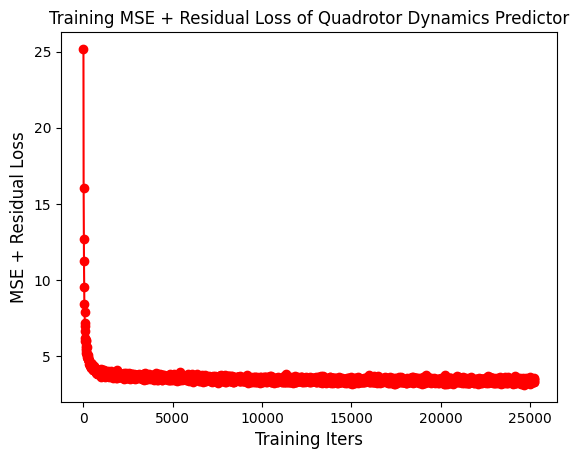

In [34]:
plt.plot(train_iter_array[1:], train_loss_array[1:],'-ro')
plt.xlabel("Training Iters",fontsize=12), plt.ylabel("MSE + Residual Loss",fontsize=12) 
plt.title("Training MSE + Residual Loss of Quadrotor Dynamics Predictor")

Text(0.5, 1.0, 'Testing MSE + Residual Loss of Quadrotor Dynamics Predictor')

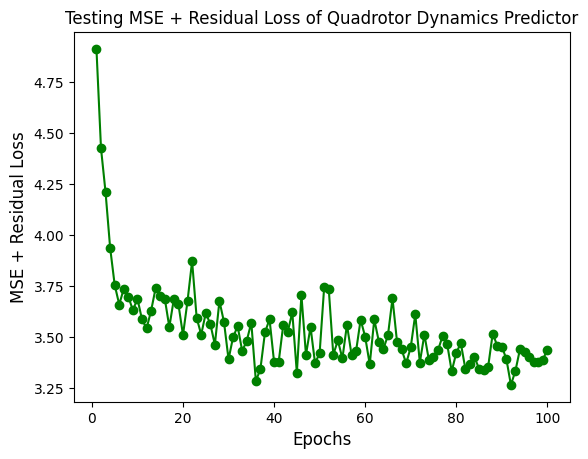

In [35]:
plt.plot(val_epoch_array[1:], val_loss_array[1:],'-go')
plt.xlabel("Epochs",fontsize=12), plt.ylabel("MSE + Residual Loss",fontsize=12) 
plt.title("Testing MSE + Residual Loss of Quadrotor Dynamics Predictor")

Text(0.5, 1.0, 'Testing MSE + Residual Loss of Quadrotor Dynamics Predictor')

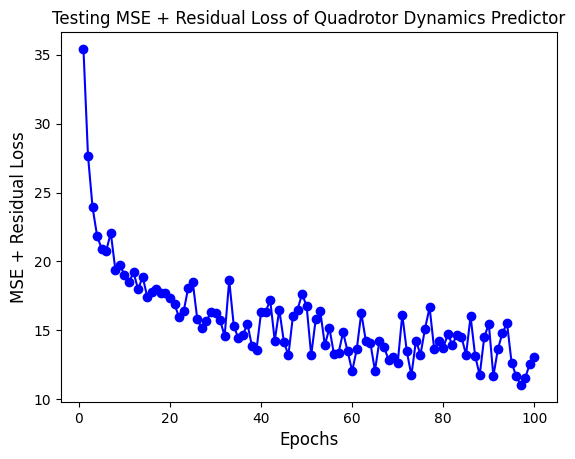

In [36]:
#val_epoch_array = np.linspace(0,57,58)

plt.plot(val_epoch_array[1:], val_AAE_array[1:],'-bo')
plt.xlabel("Epochs",fontsize=12), plt.ylabel("MSE + Residual Loss",fontsize=12) 
plt.title("Testing MSE + Residual Loss of Quadrotor Dynamics Predictor")

In [40]:
np.save('AAE_array_PINN-LSTM_pt2', val_AAE_array)

### Evaluation: Trajectory Prediction

In [63]:
def compute_AE(state_vec, pred_state_vec):
  # Computing absolute prediction error (AE)
  state_diff = np.abs(state_vec - pred_state_vec)
  AE_array = np.sum(state_diff, axis=1)
  
  return AE_array

def scaled_compute_AE(state_vec, pred_state_vec):
  # Computing absolute prediction error (AE)
  scaled_state_diff = np.abs((state_vec - pred_state_vec) / state_vec) * 100
  scaled_AE_array = np.mean(scaled_state_diff)

  return scaled_AE_array

def compute_state_RMSE(target_y, pred_y):
    """
    Compute the batch-averaged sum of RMSEs for each state at the final time step.
    
    Args:
        target_y (np.ndarray): Shape (batch_size, time_steps, state_dim)
        pred_y (np.ndarray): Shape (batch_size, time_steps, state_dim)
    
    Returns:
        float: Scalar RMSE value averaged over the batch.
    """
    # Compute squared error at the final time step
    linvel_diff_squared = (target_y[:, :3] - pred_y[:, :3]) ** 2  # Shape: (batch_size, state_dim)
    linacc_diff_squared = (target_y[:, 3:6] - pred_y[:, 3:6]) ** 2  # Shape: (batch_size, state_dim)
    angvel_diff_squared = (target_y[:, 6:9] - pred_y[:, 6:9]) ** 2  # Shape: (batch_size, state_dim)
    angacc_diff_squared = (target_y[:, 9:12] - pred_y[:, 9:12]) ** 2  # Shape: (batch_size, state_dim)
    
    # RMSE for each state in each sample
    linvel_rmse = np.sqrt(linvel_diff_squared)  # Shape: (batch_size, state_dim)
    linacc_rmse = np.sqrt(linacc_diff_squared)  # Shape: (batch_size, state_dim)
    angvel_rmse = np.sqrt(angvel_diff_squared)  # Shape: (batch_size, state_dim)
    angacc_rmse = np.sqrt(angacc_diff_squared)  # Shape: (batch_size, state_dim)
    
    # Sum RMSE across states for each sample
    summed_linvel_rmse = np.sum(linvel_rmse, axis=1)  # Shape: (batch_size,)
    summed_linacc_rmse = np.sum(linacc_rmse, axis=1)  # Shape: (batch_size,)
    summed_angvel_rmse = np.sum(angvel_rmse, axis=1)  # Shape: (batch_size,)
    summed_angacc_rmse = np.sum(angacc_rmse, axis=1)  # Shape: (batch_size,)

    return summed_linvel_rmse, summed_linacc_rmse, summed_angvel_rmse, summed_angacc_rmse


def tensor_break(traj):
    
    updated_quadout = traj.clone()
    combined_quad_array = torch.empty([updated_quadout.shape[0]*2, 35])
    for iter,i in enumerate(range(0, 2*updated_quadout.shape[0], 2)):

        added_inputs1 = updated_quadout[iter:iter+1,0,12:23]
        added_inputs2 = updated_quadout[iter:iter+1,1,12:23]

        traj1 = updated_quadout[iter:iter+1,0,:12]
        traj2 = updated_quadout[iter:iter+1,0,23:]
        traj3 = updated_quadout[iter:iter+1,1,:12]
        traj4 = updated_quadout[iter:iter+1,1,23:]
        array1 = torch.concat([traj1,added_inputs1,traj2], dim=-1)
        array2 = torch.concat([traj3,added_inputs2,traj4], dim=-1)

        traj_array = torch.concat([array1, array2], dim=0)
        combined_quad_array[i:i+2,:] = traj_array
            
    return combined_quad_array

In [82]:
pinn_model = model

In [88]:
# Initializing models used in evaluation
#model1 = torch.load('PINN-LSTM_trained_model.pt', weights_only=False)
#model2 = torch.load('large-ss-medium-disturbance-medium-noise-model.pt')
#model3 = torch.load('large-ss-slow-vel-low-noise-model.pt')
model_list = [pinn_model]
num_models = len(model_list)



# Initializing quadrotor sensor noise/disturbance parameters
num_perturb_profiles = 1
perturb_params = torch.zeros([num_perturb_profiles,2])
rotor_spike_profile = 200 
wind_vel_array = 50
perturb_params[0,0] = rotor_spike_profile
perturb_params[0,1] = wind_vel_array


# Sampling random trajectory data 
sample_length = 200
test_db = Quadrotor_Dynamics_Generator(normalize=False, device='cpu')
test_traj =  test_db.generate_test_traj(seq_length=sample_length, perturb_params=perturb_params[0,:], gaussian_noise=True)
#test_traj = torch.from_numpy(np.load('test_traj_GT.npy'))
test_traj = tensor_break(test_traj)
test_traj = db.minmax_norm(test_traj)

#print(test_traj.shape)

#test_traj = test_traj.unsqueeze(dim=0)
linvel_RMSE_array = np.zeros([num_models, sample_length])
linacc_RMSE_array = np.zeros([num_models, sample_length])
angvel_RMSE_array = np.zeros([num_models, sample_length])
angacc_RMSE_array = np.zeros([num_models, sample_length])

# Defining test trajectory time array
time_array = np.zeros([sample_length,])

# Initializing array that will contain model predictions
eval_data = torch.zeros([num_models, 2, sample_length, 12])
eval_data[:,0:1,0:1,:] = torch.tile(torch.unsqueeze(torch.unsqueeze(test_traj[0:1,:12], dim=1), dim=0), dims=[num_models, 1, 1, 1])


# Initializing plotting parameters
Xdot = np.zeros([num_models, sample_length])
Ydot = np.zeros([num_models, sample_length])
Zdot = np.zeros([num_models, sample_length])
Xddot = np.zeros([num_models, sample_length])
Yddot = np.zeros([num_models, sample_length])
Zddot = np.zeros([num_models, sample_length])

ωx = np.zeros([num_models, sample_length])
ωy = np.zeros([num_models, sample_length])
ωz = np.zeros([num_models, sample_length])
ωxdot = np.zeros([num_models, sample_length])
ωydot = np.zeros([num_models, sample_length])
ωzdot = np.zeros([num_models, sample_length])

Xdot_pred = np.zeros([num_models, sample_length])
Ydot_pred = np.zeros([num_models, sample_length])
Zdot_pred = np.zeros([num_models, sample_length])
Xddot_pred = np.zeros([num_models, sample_length])
Yddot_pred = np.zeros([num_models, sample_length])
Zddot_pred = np.zeros([num_models, sample_length])

ωx_pred = np.zeros([num_models, sample_length])
ωy_pred = np.zeros([num_models, sample_length])
ωz_pred = np.zeros([num_models, sample_length])
ωxdot_pred = np.zeros([num_models, sample_length])
ωydot_pred = np.zeros([num_models, sample_length])
ωzdot_pred = np.zeros([num_models, sample_length])


# Looping through entire test trajectory
for mdl in range(num_models):

  # Setting 'curr_model' to next model in list
  curr_model = model_list[mdl]
  
  # Resetting time counter
  curr_time = 0

  for i in range(sample_length-1):

    curr_sample = test_traj[i:i+1,:].clone()
    #print(f'{curr_sample}\n')
    
    curr_dt = curr_sample[:,12]
    curr_time += curr_dt 
    time_array[i] = curr_time[0].detach().numpy()

    input = curr_sample[:,:17]
    #batch_force_and_moments = test_forces_and_moments[idx:idx+BATCH_SIZE,-1,:]
    next_state_vecs = curr_sample[:,23:]

    # Collecting batch predicted testing outputs
    pred_state_vecs, _ = curr_model(input, mc_inference=True)

    # Computing AE of current prediction
    pred_state_vecs = test_db.minmax_unnorm(pred_state_vecs)
    next_state_vecs = test_db.minmax_unnorm(next_state_vecs)
    #print(f'context_y: {context_y}\n')

    # Computing AE of current prediction
    linvel_rmse, linacc_rmse, angvel_rmse, angacc_rmse = compute_state_RMSE(next_state_vecs.detach().numpy(), pred_state_vecs.detach().numpy())
    linvel_RMSE_array[mdl, i] = linvel_rmse
    linacc_RMSE_array[mdl, i] = linacc_rmse
    angvel_RMSE_array[mdl, i] = angvel_rmse
    angacc_RMSE_array[mdl, i] = angacc_rmse

    eval_data[mdl,0:1,i:i+1,:] = next_state_vecs
    eval_data[mdl,1:2,i-1:i+1,:] = pred_state_vecs
    

  # Storing true states, their predictions, and associated variances for plotting
  Xdot[mdl,:] = eval_data[mdl,0,:,0].detach().numpy()
  Ydot[mdl,:] = eval_data[mdl,0,:,1].detach().numpy() 
  Zdot[mdl,:] = eval_data[mdl,0,:,2].detach().numpy()
  Xddot[mdl,:] = eval_data[mdl,0,:,3].detach().numpy() 
  Yddot[mdl,:] = eval_data[mdl,0,:,4].detach().numpy()
  Zddot[mdl,:] = eval_data[mdl,0,:,5].detach().numpy() 


  Xdot_pred[mdl,:] = eval_data[mdl,1,:,0].detach().numpy() 
  Ydot_pred[mdl,:] = eval_data[mdl,1,:,1].detach().numpy() 
  Zdot_pred[mdl,:] = eval_data[mdl,1,:,2].detach().numpy() 
  Xddot_pred[mdl,:] = eval_data[mdl,1,:,3].detach().numpy() 
  Yddot_pred[mdl,:] = eval_data[mdl,1,:,4].detach().numpy()
  Zddot_pred[mdl,:] = eval_data[mdl,1,:,5].detach().numpy()

  
  ωx[mdl,:] = eval_data[mdl,0,:,6].detach().numpy() 
  ωy[mdl,:] = eval_data[mdl,0,:,7].detach().numpy() 
  ωz[mdl,:] = eval_data[mdl,0,:,8].detach().numpy() 
  ωxdot[mdl,:] = eval_data[mdl,0,:,9].detach().numpy()
  ωydot[mdl,:] = eval_data[mdl,0,:,10].detach().numpy() 
  ωzdot[mdl,:] = eval_data[mdl,0,:,11].detach().numpy() 
  
  ωx_pred[mdl,:] = eval_data[mdl,1,:,6].detach().numpy() 
  ωy_pred[mdl,:] = eval_data[mdl,1,:,7].detach().numpy() 
  ωz_pred[mdl,:] = eval_data[mdl,1,:,8].detach().numpy()
  ωxdot_pred[mdl,:] = eval_data[mdl,1,:,9].detach().numpy()
  ωydot_pred[mdl,:] = eval_data[mdl,1,:,10].detach().numpy() 
  ωzdot_pred[mdl,:] = eval_data[mdl,1,:,11].detach().numpy()


batch_linvel_rmse = np.mean(linvel_RMSE_array, axis=1)
batch_linacc_rmse = np.mean(linacc_RMSE_array, axis=1)
batch_angvel_rmse = np.mean(angvel_RMSE_array, axis=1)
batch_angacc_rmse = np.mean(angacc_RMSE_array, axis=1)

batch_linvel_rmse_std = np.std(linvel_RMSE_array, axis=1)
batch_linacc_rmse_std = np.std(linacc_RMSE_array, axis=1)
batch_angvel_rmse_std = np.std(angvel_RMSE_array, axis=1)
batch_angacc_rmse_std = np.std(angacc_RMSE_array, axis=1)

print(f'Batch Linear Velocity RMSE: {batch_linvel_rmse} ± {batch_linvel_rmse_std}')
print(f'Batch Linear Acceleration RMSE: {batch_linacc_rmse} ± {batch_linacc_rmse_std}')
print(f'Batch Angular Velocity RMSE: {batch_angvel_rmse} ± {batch_angvel_rmse_std}')
print(f'Batch Angular Acceleration RMSE: {batch_angacc_rmse} ± {batch_angacc_rmse_std}')

/tmp/ipykernel_4064/1686058429.py:105: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  linvel_RMSE_array[mdl, i] = linvel_rmse
/tmp/ipykernel_4064/1686058429.py:106: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  linacc_RMSE_array[mdl, i] = linacc_rmse
/tmp/ipykernel_4064/1686058429.py:107: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  angvel_RMSE_array[mdl, i] = angvel_rmse
/tmp/ipykernel_4064/1686058429.py:108: DeprecationWarning: Conversion of an array with ndim > 

Batch Linear Velocity RMSE: [15.93180503] ± [10.26410122]
Batch Linear Acceleration RMSE: [9.90577959] ± [4.0996799]
Batch Angular Velocity RMSE: [3.80040668] ± [2.36229476]
Batch Angular Acceleration RMSE: [6.34378342] ± [4.24391945]


In [22]:
# Defining length of plotted trajectories (ensure its <= to sample_length)
plt_idx = 199

(Text(0.5, 0, 'Time (s)'), Text(0, 0.5, '$\\dot{X}$ (m/s)'))

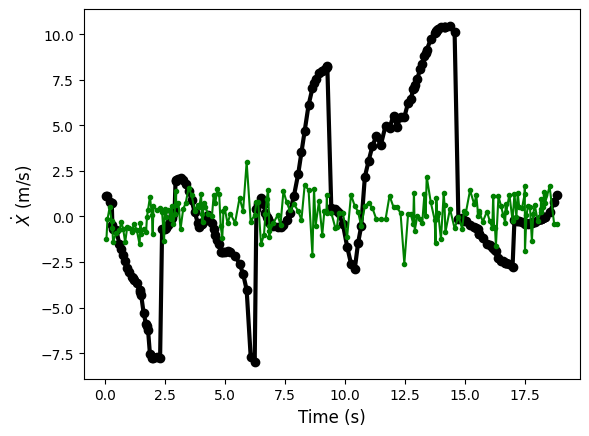

In [ ]:
plt.plot(time_array[:plt_idx], Xdot[0,:plt_idx], '-ko', linewidth=3)
plt.plot(time_array[:plt_idx], Xdot_pred[0,:plt_idx], '-go', markersize=3)

plt.xlabel("Time (s)", fontsize=12), plt.ylabel(r"$\dot{X}$ (m/s)", fontsize=12)

(Text(0.5, 0, 'Time (s)'), Text(0, 0.5, '$\\dot{Y}$ (m/s)'))

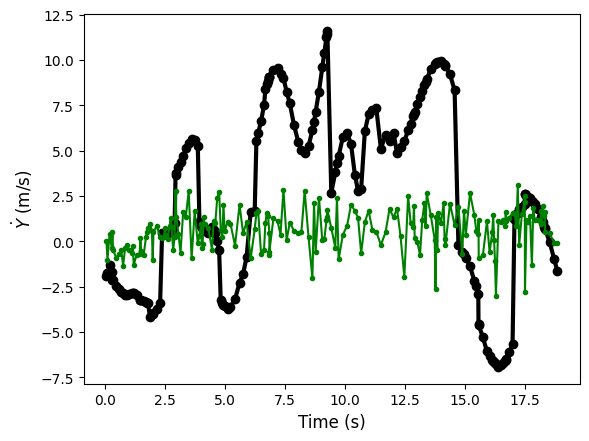

In [ ]:
plt.plot(time_array[:plt_idx], Ydot[0,:plt_idx], '-ko', linewidth=3)
plt.plot(time_array[:plt_idx], Ydot_pred[0,:plt_idx], '-go', markersize=3)

plt.xlabel("Time (s)", fontsize=12), plt.ylabel(r"$\dot{Y}$ (m/s)", fontsize=12)

(Text(0.5, 0, 'Time (s)'), Text(0, 0.5, '$\\dot{Z}$ (m/s)'))

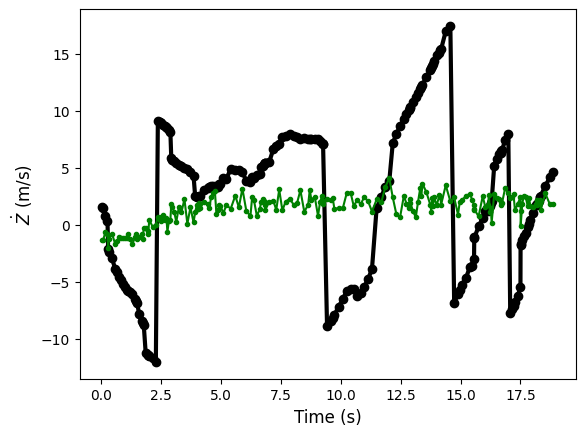

In [ ]:
plt.plot(time_array[:plt_idx], Zdot[0,:plt_idx], '-ko', linewidth=3)
plt.plot(time_array[:plt_idx], Zdot_pred[0,:plt_idx], '-go', markersize=3)

plt.xlabel("Time (s)", fontsize=12), plt.ylabel(r"$\dot{Z}$ (m/s)", fontsize=12)

(Text(0.5, 0, 'Time (s)'), Text(0, 0.5, '$\\dot{\\omega}_{x}$ (rad/s)'))

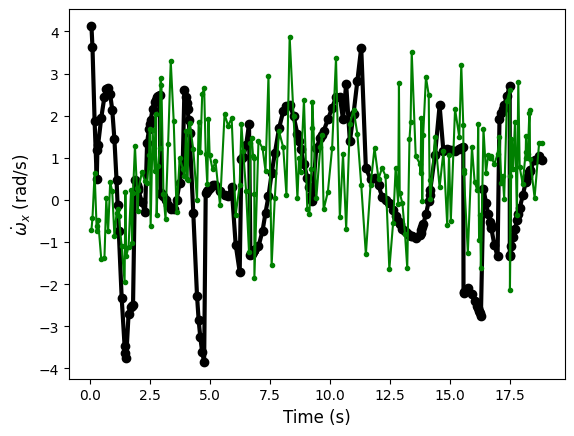

In [ ]:
plt.plot(time_array[:plt_idx], ωx[0,:plt_idx], '-ko', linewidth=3)
plt.plot(time_array[:plt_idx], ωx_pred[0,:plt_idx], '-go', markersize=3)

plt.xlabel("Time (s)", fontsize=12), plt.ylabel(r"$\dot{\omega}_{x}$ (rad/s)", fontsize=12)

(Text(0.5, 0, 'Time (s)'), Text(0, 0.5, '$\\dot{\\omega}_{y}$ (rad/s)'))

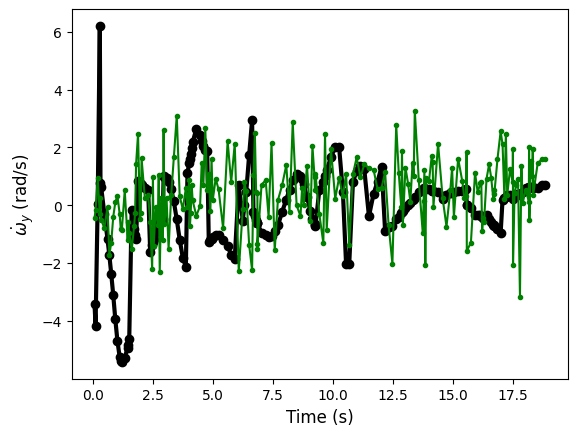

In [ ]:
plt.plot(time_array[:plt_idx], ωy[0,:plt_idx], '-ko', linewidth=3)
plt.plot(time_array[:plt_idx], ωy_pred[0,:plt_idx], '-go', markersize=3)

plt.xlabel("Time (s)", fontsize=12), plt.ylabel(r"$\dot{\omega}_{y}$ (rad/s)", fontsize=12)

(Text(0.5, 0, 'Time (s)'), Text(0, 0.5, '$\\dot{\\omega}_{z}$ (rad/s)'))

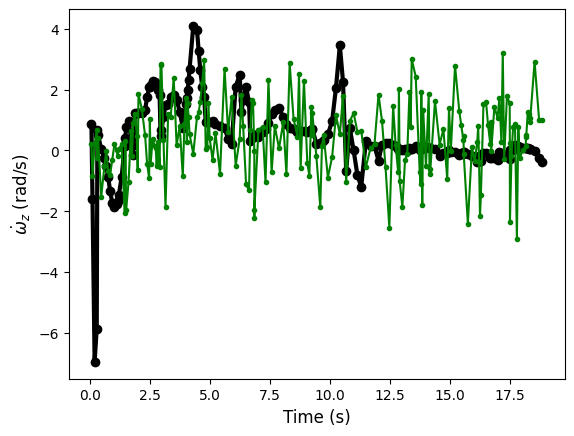

In [ ]:
plt.plot(time_array[:plt_idx], ωz[0,:plt_idx], '-ko', linewidth=3)
plt.plot(time_array[:plt_idx], ωz_pred[0,:plt_idx], '-go', markersize=3)

plt.xlabel("Time (s)", fontsize=12), plt.ylabel(r"$\dot{\omega}_{z}$ (rad/s)", fontsize=12)